# Gravitational waveforms and the detector response

To find a signal in the data we need to know what it looks like. That prediction has two parts:

1. **What the source emits.** A *waveform model* (also called an **approximant**) predicts the two polarizations of the wave, $h_+(t)$ and $h_\times(t)$, for given masses, spins and distance.
2. **What the detector records.** A detector does not see $h_+$ and $h_\times$ separately, but a mix of the two that depends on where the source is on the sky. The mixing weights are the **antenna pattern functions** $F_+$ and $F_\times$:

$$
h(t) = F_+\, h_+(t) + F_\times\, h_\times(t).
$$

## Setup

In [2]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np

from pycbc.detector import Detector
from pycbc.waveform import get_td_waveform, get_fd_waveform
from pycbc.waveform.utils import amplitude_from_polarizations, frequency_from_polarizations

%config InlineBackend.figure_format = 'retina'

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


## Generating a waveform

### What does a waveform model do?

Two black holes orbiting each other lose energy by emitting gravitational waves. As they lose energy the orbit shrinks, so they move faster and closer, and emit even more strongly. The result is a wave whose **amplitude and frequency both grow** until the black holes merge.

Predicting this wave exactly means solving Einstein's equations for two black holes. That can be done with **numerical relativity** (NR) simulations, but each one takes weeks to months on a supercomputer. Searches and parameter estimation need millions of waveforms, so we use **waveform models** (also called **approximants**): approximate recipes that give $h_+(t)$ and $h_\times(t)$ in a fraction of a second. They combine three pieces of physics, one for each stage of the signal:

- **Inspiral**, when the black holes are still far apart and slow: **post-Newtonian theory**, an expansion of general relativity in powers of $v/c$.
- **Merger**, when they move at a large fraction of the speed of light: no simple approximation works, so the models are **calibrated to NR simulations**.
- **Ringdown**, when the final black hole settles down: **black-hole perturbation theory**. The remnant "rings" at a frequency set by its mass and spin.

**How are the models actually built?** Very briefly:

- **Post-Newtonian models** (`Taylor`): energy balance. The orbital energy $E$ and the power $P$ carried away by the waves are known as series in $v/c$. Solving $dE/dt = -P$ tells how fast the orbit shrinks, and so gives the phase of the wave. Inspiral only.
- **Phenomenological models** (`IMRPhenom`): the waveform is written in the frequency domain as $\tilde h(f) = A(f)\, e^{-i\Psi(f)}$. Amplitude and phase are simple formulas, glued together in three frequency ranges (inspiral, intermediate, merger-ringdown), whose coefficients are fitted to NR simulations as functions of the mass ratio and spins. Very fast.
- **Effective-one-body models** (`SEOBNR`): the two bodies are replaced by one effective body moving in a deformed black-hole spacetime. Its orbit is evolved by solving differential equations, the wave is computed from the orbit, and the ringdown is attached at the end as a sum of damped oscillations. Calibrated to NR.
- **NR surrogates** (`NRSur`): interpolate directly between a set of NR simulations. Very accurate, but only within the range covered by the simulations.

`pycbc` gives one common interface to all the models of the LIGO-Virgo-KAGRA library LALSimulation:

In [3]:
from pycbc.waveform import td_approximants

print(len(td_approximants()), "approximants available, for example:")
print(["TaylorT4", "IMRPhenomD", "IMRPhenomXPHM", "SEOBNRv4", "NRSur7dq4"])

83 approximants available, for example:
['TaylorT4', 'IMRPhenomD', 'IMRPhenomXPHM', 'SEOBNRv4', 'NRSur7dq4']


### What goes in and what comes out

You give `get_td_waveform` the properties of the binary, plus two technical settings:

| argument | meaning |
|---|---|
| `approximant` | which waveform model to use |
| `mass1`, `mass2` | masses of the two objects, in solar masses, **as seen by the detector** |
| `spin1z`, `spin2z` | spins along the orbital axis, between $-1$ and $1$ (default 0) |
| `distance` | luminosity distance, in Mpc |
| `inclination` | angle between the orbital axis and our line of sight (default 0) |
| `delta_t` | time between samples, in s. It fixes the highest frequency the time series can contain, $1/(2\,\Delta t)$: 2048 Hz for $\Delta t = 1/4096$ s |
| `f_lower` | gravitational-wave frequency, in Hz, at which the waveform starts.|

**Source-frame or detector-frame masses?** The wave travels across an expanding Universe, so it arrives stretched by a factor $1+z$, where $z$ is the source's redshift: all its frequencies are lower and the signal lasts longer. A binary with masses $m_1, m_2$ at redshift $z$ produces exactly the same signal as a binary with masses $(1+z)\,m_1, (1+z)\,m_2$ that is not redshifted. Waveform generators therefore take the **detector-frame** (redshifted) masses, $m^{\rm det} = (1+z)\, m^{\rm source}$, and `pycbc` does not apply the redshift for you; `distance` is the luminosity distance.

The masses and spins set the **shape** of the signal: how long it lasts and how its frequency evolves. The distance and inclination only set **how loud** it is and how it splits between the two polarizations. What comes out are two `pycbc` `TimeSeries`, $h_+(t)$ and $h_\times(t)$: plain arrays of numbers, one every `delta_t` seconds, with time $t = 0$ at the merger. The values are dimensionless strains, i.e. fractional changes in length, of order $10^{-21}$.

We use `IMRPhenomD`, which covers the whole signal (**inspiral, merger and ringdown**, IMR): two black holes of 36 and 29 $M_\odot$ at 400 Mpc.

65536 samples, -11.0 to 5.0 s, peak strain 1.88e-21


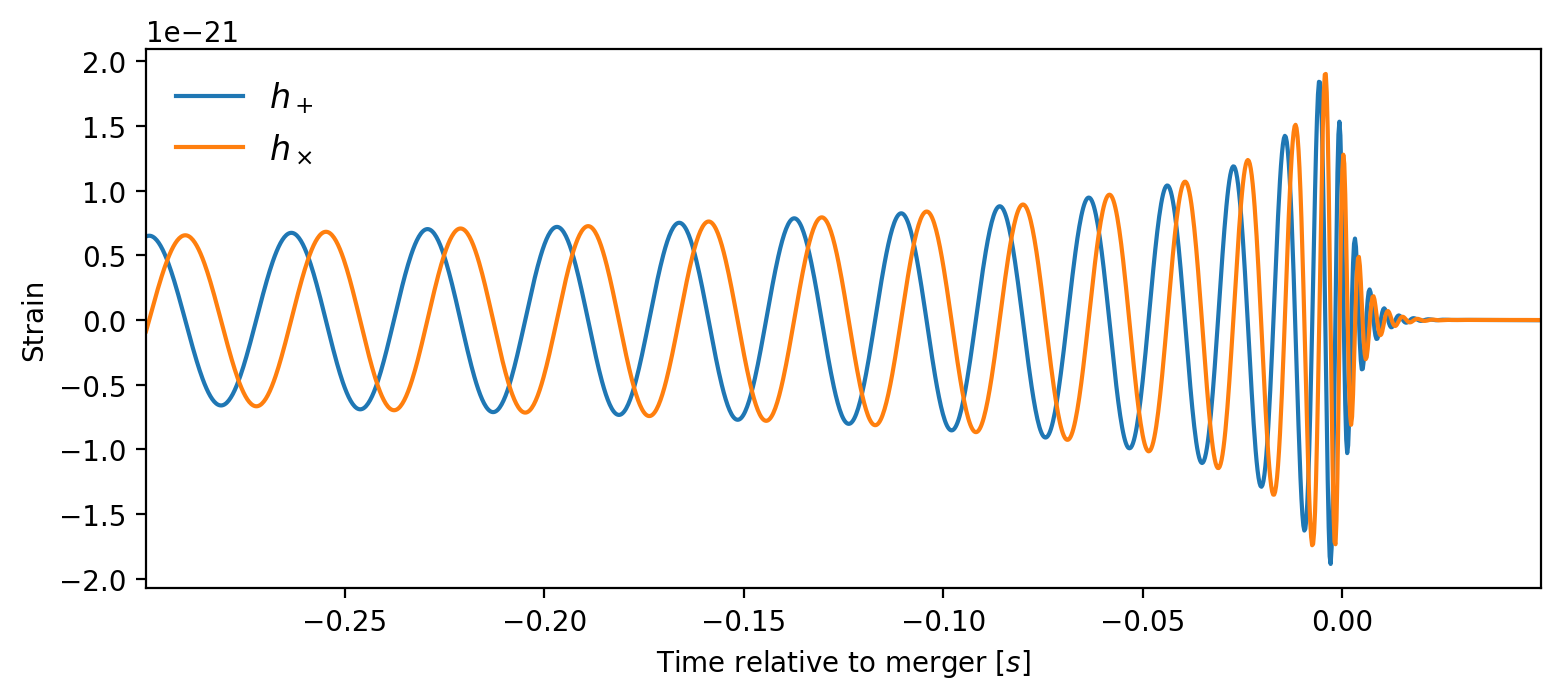

In [4]:
hp, hc = get_td_waveform(approximant="IMRPhenomD", mass1=36, mass2=29, distance=400,
                         delta_t=1 / 4096, f_lower=20)
t = hp.sample_times.numpy()

print(f"{len(hp)} samples, {t[0]:.1f} to {t[-1]:.1f} s, peak strain {np.abs(hp).numpy().max():.2e}")

around = (t > -0.3) & (t < 0.05)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t[around], hp.numpy()[around], label="$h_+$", color="C0", lw=1.5)
ax.plot(t[around], hc.numpy()[around], label="$h_\\times$", color="C1", lw=1.5)
plt.xlim(t[around][0], t[around][-1])
ax.set_xlabel("Time relative to merger $[s]$")
ax.set_ylabel("Strain")
ax.legend(frameon=False, fontsize=12, loc="upper left")
plt.show()

This is the typical **chirp**:

- **inspiral**: the black holes orbit each other faster and faster, so the wave grows in amplitude and frequency;
- **merger**: the amplitude peaks when the two black holes become one;
- **ringdown**: the final black hole settles down and the signal quickly dies away.

### Inclination

The viewing angle $\iota$ (the `inclination`) changes how the wave splits between the two polarizations:

$$
h_+(t) = A(t)\,\frac{1+\cos^2\iota}{2}\,\cos\Phi(t), \qquad h_\times(t) = A(t)\,\cos\iota\,\sin\Phi(t).
$$

Let's look at three viewing angles.

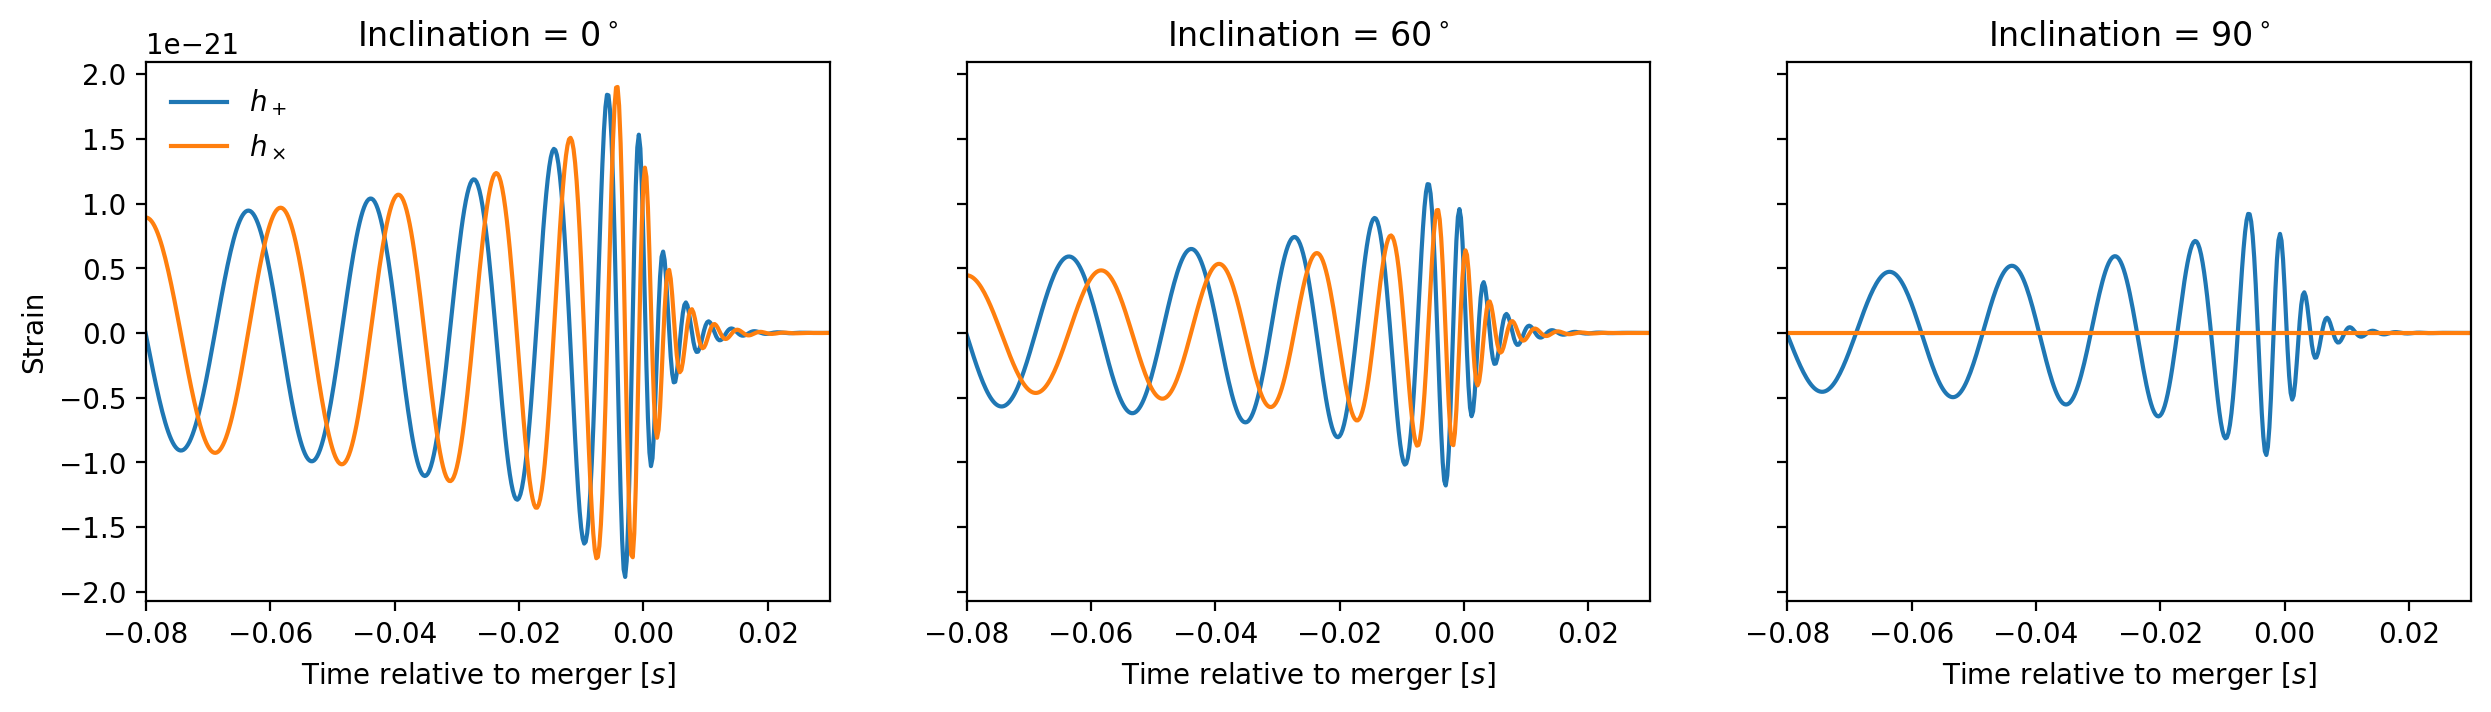

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)

for ax, inclination_deg in zip(axes, [0, 60, 90]):
    hp_i, hc_i = get_td_waveform(approximant="IMRPhenomD", mass1=36, mass2=29, distance=400,
                                 inclination=np.radians(inclination_deg), delta_t=1 / 4096, f_lower=20)
    ax.plot(hp_i.sample_times, hp_i, label="$h_+$")
    ax.plot(hc_i.sample_times, hc_i, label="$h_\\times$")
    ax.set_xlim(-0.08, 0.03)
    ax.set_title(f"Inclination = {inclination_deg}$^\\circ$")
    ax.set_xlabel("Time relative to merger $[s]$")

axes[0].set_ylabel("Strain")
axes[0].legend(frameon=False, loc="upper left")
plt.show()

- **Face-on** ($0^\circ$): $h_+$ and $h_\times$ have the same size. We see the orbit as a circle, and the wave is *circularly polarized*.
- **Edge-on** ($90^\circ$): $h_\times$ vanishes and $h_+$ is halved. We see the orbit as a line, and the wave is *linearly polarized*.

So the same binary is louder seen face-on than edge-on. This also means distance and inclination are hard to tell apart: a far face-on binary can look much like a closer, more inclined one.

## Inspiral-only vs. full inspiral-merger-ringdown

Older and simpler waveform models describe only the **inspiral**. They come from post-Newtonian theory, which works well while the black holes are still far apart and moving slowly, but breaks down near the merger. We compare one of them with the full `IMRPhenomD` model.

Many models are written directly in the frequency domain, $\tilde h(f)$, so we compare them there. The inspiral-only model is `TaylorF2`.

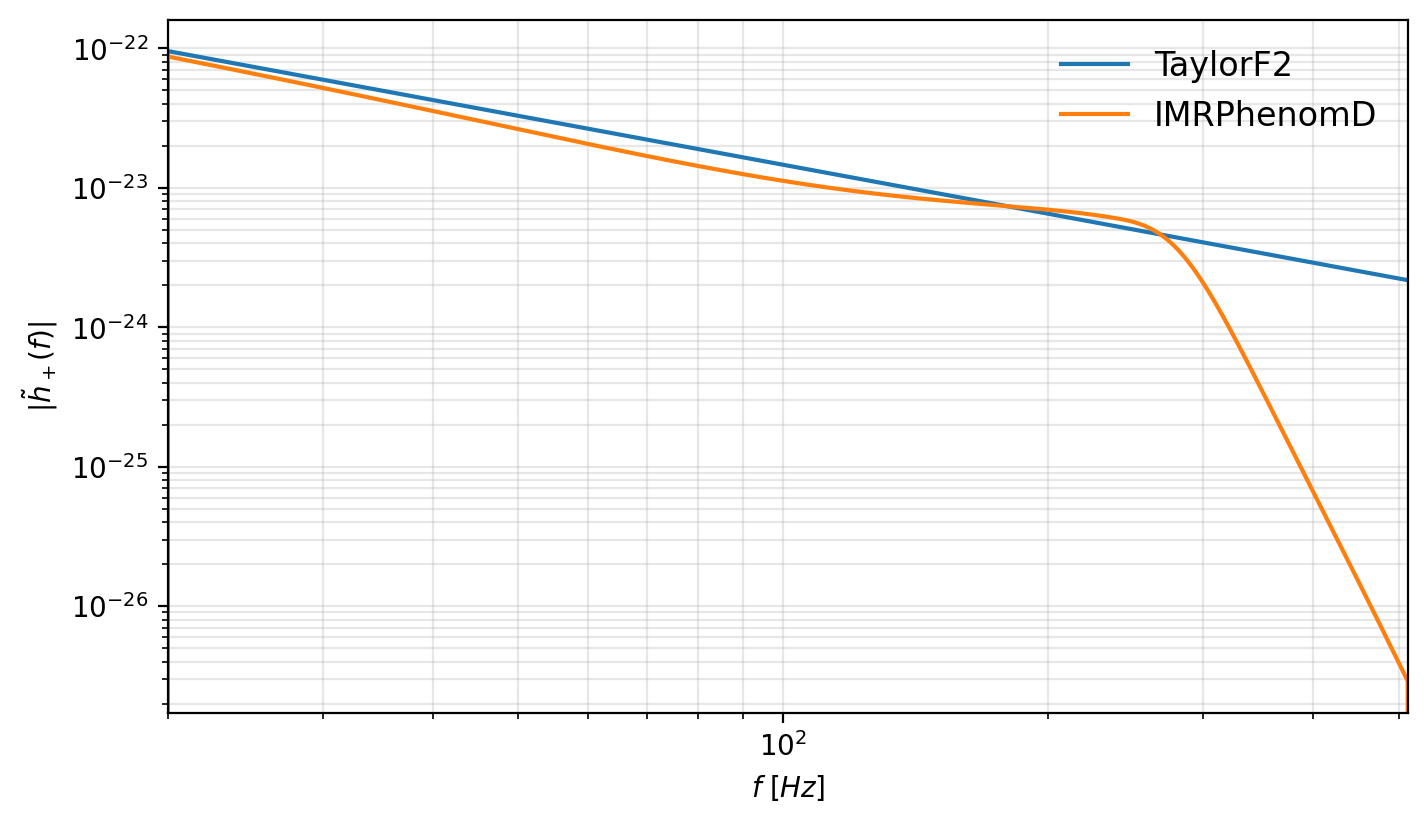

In [7]:
f_lower, f_final, delta_f = 20.0, 512.0, 1 / 16

hp_taylor, hc_taylor = get_fd_waveform(approximant="TaylorF2", mass1=36, mass2=29, distance=400,
                                       delta_f=delta_f, f_lower=f_lower, f_final=f_final)
hp_imr, hc_imr = get_fd_waveform(approximant="IMRPhenomD", mass1=36, mass2=29, distance=400,
                                 delta_f=delta_f, f_lower=f_lower, f_final=f_final)
freqs = hp_taylor.sample_frequencies.numpy()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.loglog(freqs, np.abs(hp_taylor.numpy()), label="TaylorF2")
ax.loglog(freqs, np.abs(hp_imr.numpy()), label="IMRPhenomD")
ax.set_xlabel("$f$ $[Hz]$")
ax.set_ylabel(r"$|\tilde h_+(f)|$")
ax.set_xlim(f_lower, f_final)
ax.legend(frameon=False, fontsize=12)
ax.grid(alpha=0.3, which="both")
plt.show()

Like `get_td_waveform`, `get_fd_waveform` returns both polarizations, $\tilde h_+(f)$ and $\tilde h_\times(f)$. We plot only $|\tilde h_+(f)|$. For this face-on binary, in both models $\tilde h_\times(f) = -i\,\tilde h_+(f)$ at every frequency: the quarter-cycle shift between $h_+$ and $h_\times$ that we saw in the time domain becomes a factor $-i$ in the frequency domain. Since $|-i| = 1$, the curves for $|\tilde h_\times(f)|$ would be exactly the same.

## Antenna pattern funtions

A detector does not record $h_+$ and $h_\times$ separately. More precisely, the input and output of the detector are scalar quantities, while the GW is described by a tensor $h_{ij}$. So, in general, the input of the detector will have the form

$$
h(t) = D^{ij}h_{ij}(t)
$$

 An interferometer measures how much one arm is stretched compared to the other, which gives a single number at each time: a weighted sum of the two polarizations (Maggiore, *Gravitational Waves, Vol. 1*, Sec. 7.2, eq. 7.22),

$$
h(t) = F_+\, h_+(t) + F_\times\, h_\times(t).
$$

The weights $F_+$ and $F_\times$ are the **antenna pattern functions**. They are numbers between $-1$ and $1$ that depend only on geometry, not on the source's masses or distance:

- the **sky position** of the source, given by its right ascension $\alpha$ and declination $\delta$;
- the **polarization angle** $\psi$, which fixes the axes used to define $h_+$ and $h_\times$. Changing $\psi$ moves signal between $F_+$ and $F_\times$, but leaves $F_+^2 + F_\times^2$ unchanged;
- the **time**, because the detector turns with the Earth while the source stays fixed on the sky.

`pycbc.detector.Detector` knows where each detector is and how its arms point. `antenna_pattern(ra, dec, psi, t_gps)` returns $F_+$ and $F_\times$. Let's compute them for LIGO Hanford (H1), for a source at a sky position consistent with GW150914, at the time of that event, and build $h(t)$ from the waveform of Section 1.

H1: F+ = +0.579, Fx = -0.451


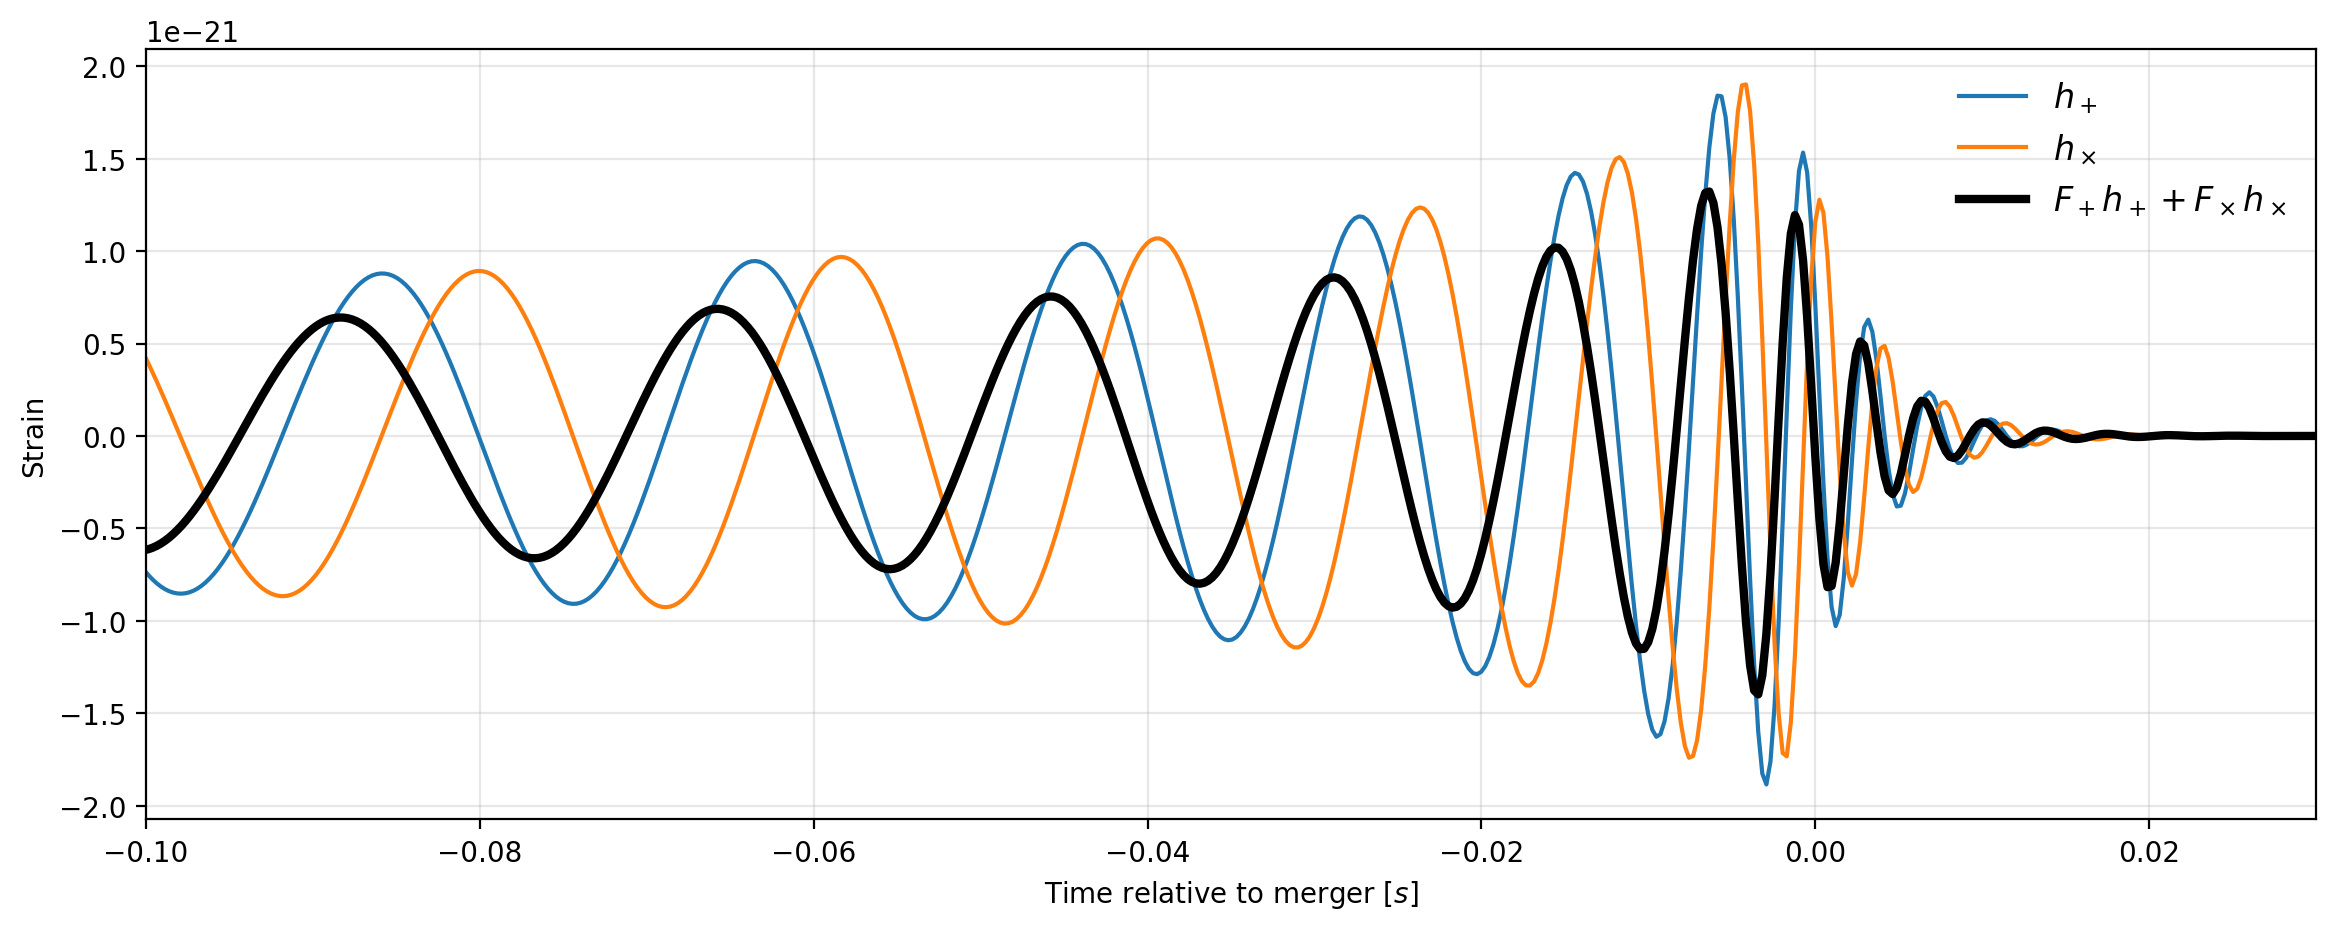

In [6]:
t_gps = 1126259462.4                    # GPS time of GW150914
ra, dec, psi = 1.95, -1.27, 0.82        # sky position (radians) and polarization angle

H1 = Detector("H1")
f_plus, f_cross = H1.antenna_pattern(ra, dec, psi, t_gps)
print(f"H1: F+ = {f_plus:+.3f}, Fx = {f_cross:+.3f}")

h_detector = f_plus * hp + f_cross * hc

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hp.sample_times, hp, label="$h_+$", color="C0", lw=1.5)
ax.plot(hc.sample_times, hc, label="$h_\\times$", color="C1", lw=1.5)
ax.plot(h_detector.sample_times, h_detector, color="k", label="$F_+ h_+ + F_\\times h_\\times$", lw=3)
ax.set_xlim(-0.1, 0.03)
ax.set_xlabel("Time relative to merger $[s]$")
ax.set_ylabel("Strain")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=12, frameon=False)
plt.show()

The detector sees a smaller version of the wave. For this face-on binary, $h_+$ and $h_\times$ have the same size and are a quarter cycle apart, so the recorded signal is the wave scaled by $\sqrt{F_+^2 + F_\times^2}$ and slightly shifted in phase.

### The antenna pattern on the sky

Repeating this for every sky position shows which directions the detector is sensitive to. Besides $F_+$ and $F_\times$ (for $\psi = 0$), we plot the combination $F_{\rm tot} = \sqrt{F_+^2 + F_\times^2}$, which does not depend on $\psi$ and so measures the overall sensitivity to each direction.

The maps show the whole sky: right ascension horizontally, declination vertically.

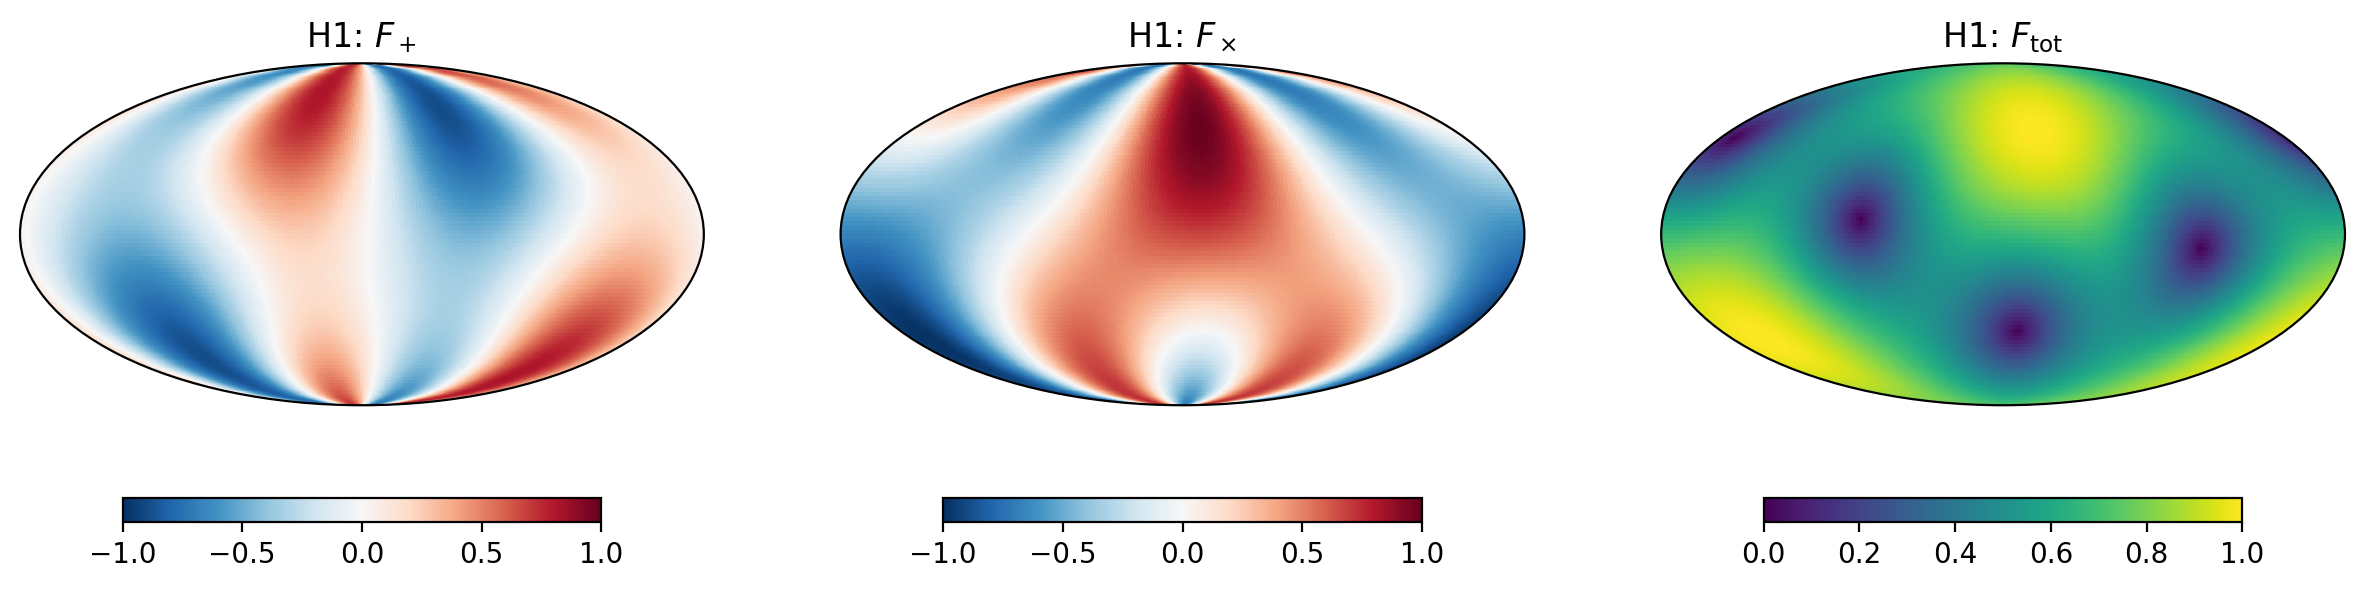

In [7]:
# grid of sky positions: right ascension (horizontal) and declination (vertical), in radians
ra_grid, dec_grid = np.meshgrid(np.linspace(-np.pi, np.pi, 200), np.linspace(-np.pi / 2, np.pi / 2, 100))

# H1's antenna patterns at every sky position (psi = 0)
f_plus_sky, f_cross_sky = H1.antenna_pattern(ra_grid.ravel(), dec_grid.ravel(), 0.0, t_gps)
f_plus_sky = f_plus_sky.reshape(ra_grid.shape)
f_cross_sky = f_cross_sky.reshape(ra_grid.shape)
F_tot_sky = np.sqrt(f_plus_sky ** 2 + f_cross_sky ** 2)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1, projection="mollweide")
plt.pcolormesh(ra_grid, dec_grid, f_plus_sky, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(orientation="horizontal", shrink=0.7)
plt.title("H1: $F_+$")
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 2, projection="mollweide")
plt.pcolormesh(ra_grid, dec_grid, f_cross_sky, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(orientation="horizontal", shrink=0.7)
plt.title("H1: $F_\\times$")
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 3, projection="mollweide")
plt.pcolormesh(ra_grid, dec_grid, F_tot_sky, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(orientation="horizontal", shrink=0.7)
plt.title("H1: $F_{\\rm tot}$")
plt.xticks([])
plt.yticks([])

plt.show()

Each detector sits at a different place on the Earth, with its arms pointing in different directions, so it has its own $F_+$ and $F_\times$. The wave also reaches each detector at a slightly different time. `project_wave` takes care of both, returning the signal each detector records:

$$
h(t) = F_+\, h_+(t - \Delta t) + F_\times\, h_\times(t - \Delta t),
$$

where $\Delta t$ is the extra time the wave takes to reach that detector compared to the Earth's centre. We use LIGO Hanford (H1), LIGO Livingston (L1) and Virgo (V1), with the same source position and time as above, and a binary seen nearly face-off (inclination $155^\circ$, as for the real GW150914).

In [8]:
hp_src, hc_src = get_td_waveform(approximant="IMRPhenomD", mass1=36, mass2=29, distance=400,
                                 inclination=np.radians(155), delta_t=1 / 4096, f_lower=20)
hp_src.start_time += t_gps              # put the merger at t_gps
hc_src.start_time += t_gps

H1 = Detector("H1")
L1 = Detector("L1")
V1 = Detector("V1")

# The signal recorded by each detector
h_H1 = H1.project_wave(hp_src, hc_src, ra, dec, psi)
h_L1 = L1.project_wave(hp_src, hc_src, ra, dec, psi)
h_V1 = V1.project_wave(hp_src, hc_src, ra, dec, psi)

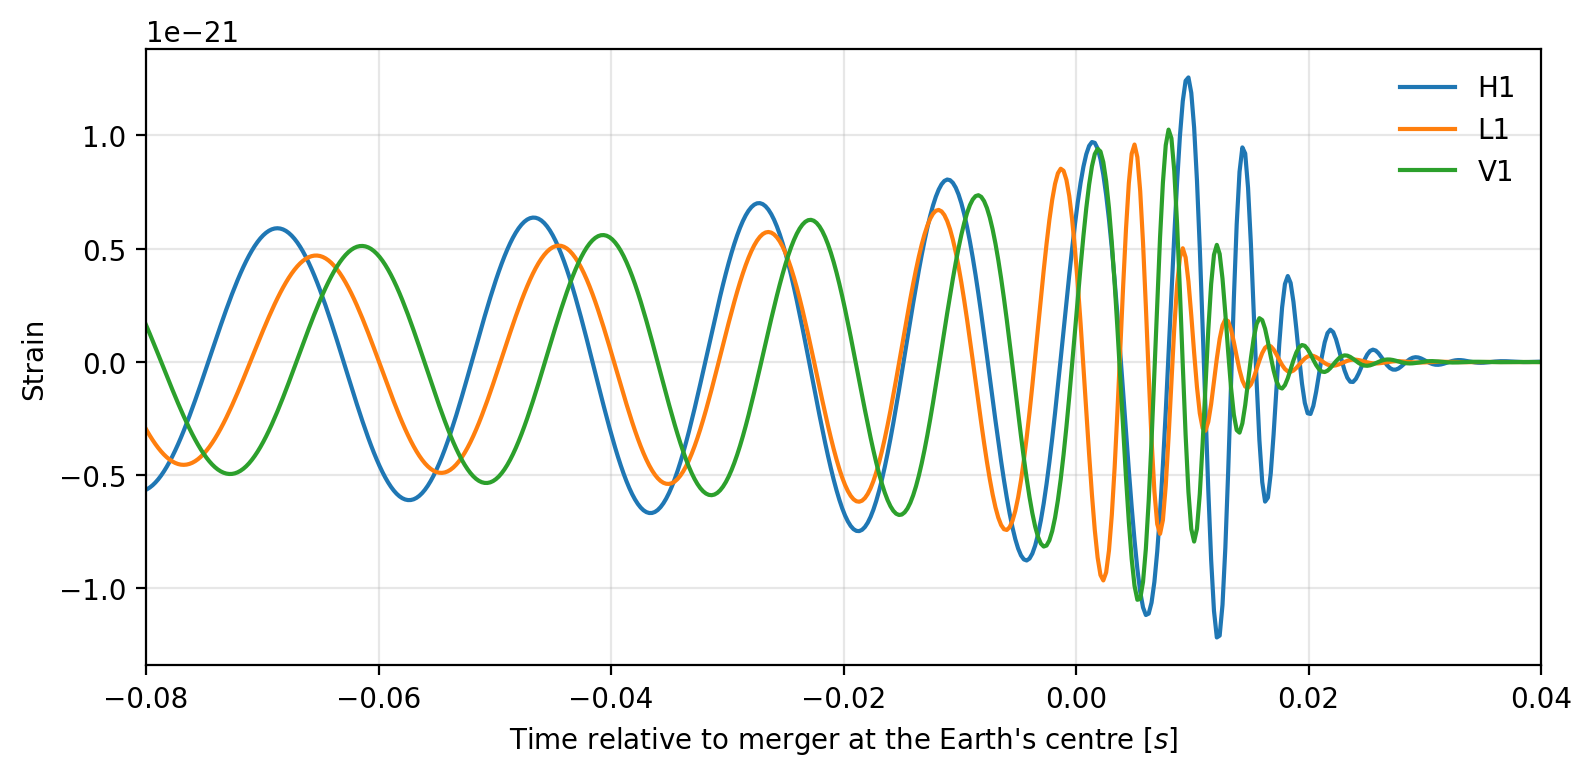

In [9]:
# comment out a line to hide that detector
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(h_H1.sample_times - t_gps, h_H1, label="H1", color="C0", lw=1.5)
ax.plot(h_L1.sample_times - t_gps, h_L1, label="L1", color="C1", lw=1.5)
ax.plot(h_V1.sample_times - t_gps, h_V1, label="V1", color="C2", lw=1.5)
ax.set_xlim(-0.08, 0.04)
ax.set_xlabel("Time relative to merger at the Earth's centre $[s]$")
ax.set_ylabel("Strain")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.show()